In [ ]:
from google.colab import drive

In [ ]:
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# **Installing required libraries**

1.   AI + visualization libraries
2.   Load image datasets
3.   Loading data in batches
4.   Visualization libraries
5.   Pretrained models
6.   Image handling
7.   Grad-CAM for explainable AI
8.   Gen AI (text to image)



In [12]:
# Install required AI + visualization libraries
!pip install diffusers transformers scipy safetensors accelerate --quiet  # for Stable Diffusion (text-to-image)
!pip install torchvision --upgrade --quiet  # ensures latest vision models
!pip install torchcam --quiet  # for Grad-CAM

import os
import shutil  # for copying, moving, deleting files

# Load image datasets and apply transformations
from torchvision import datasets, transforms

# For loading data in batches
from torch.utils.data import DataLoader, random_split

# Visualization libraries
import matplotlib.pyplot as plt  # for charts and images
import cv2  # for image processing

# basic libraries for model training
import torch
import torch.nn as nn
import torch.optim as optim

# Pretrained models
from torchvision import models  # access model zoo
from torchvision.models import resnet18, ResNet18_Weights  # ResNet18
from torchvision.models import densenet201, DenseNet201_Weights  # DenseNet201

# Image handling
from PIL import Image
import numpy as np
import torchvision  # for things like utils.make_grid()

# Metrics and confusion matrix
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Grad-CAM for explainable AI
from torchcam.methods import GradCAM
from torchvision.transforms.functional import to_pil_image  # convert tensors to image

# Stable Diffusion for text-to-image generation
from diffusers import StableDiffusionPipeline

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.0/46.0 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.3/18.3 MB 56.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 90.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 63.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 45.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 738.0 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 6.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 13.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 7.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 6.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

# **Get the Dataset**

In [ ]:
# The data is being taken from Kaggle and stored in drive
# Link for the dataset --> https://www.kaggle.com/datasets/brsdincer/danger-of-extinction-animal-image-set
!unzip "/content/drive/MyDrive/00_Data.zip" -d "/content/endangered_species"

Streaming output truncated to the last 5000 lines.
  inflating: /content/endangered_species/Danger Of Extinction/Chimpanzee/216.jpg  
  inflating: /content/endangered_species/Danger Of Extinction/Chimpanzee/217.jpg  
  inflating: /content/endangered_species/Danger Of Extinction/Chimpanzee/218.jpg  
  inflating: /content/endangered_species/Danger Of Extinction/Chimpanzee/219.jpg  
  inflating: /content/endangered_species/Danger Of Extinction/Chimpanzee/22.jpg  
  inflating: /content/endangered_species/Danger Of Extinction/Chimpanzee/220.jpg  
  inflating: /content/endangered_species/Danger Of Extinction/Chimpanzee/221.jpg  
  inflating: /content/endangered_species/Danger Of Extinction/Chimpanzee/222.jpg  
  inflating: /content/endangered_species/Danger Of Extinction/Chimpanzee/223.jpg  
  inflating: /content/endangered_species/Danger Of Extinction/Chimpanzee/224.jpg  
  inflating: /content/endangered_species/Danger Of Extinction/Chimpanzee/225.jpg  
  inflating: /content/endangered_spec

In [ ]:
# gives files in the unzipped data
print(os.listdir('/content/endangered_species'))

['Danger Of Extinction']


In [ ]:
d0_path = '/content/endangered_species/Danger Of Extinction'

# Show all animal categories inside the dataset
print(os.listdir(d0_path))

['Chimpanzee', 'African_Elephant', 'Amur_Leopard', 'Lion', 'Rhino', 'Orangutan', 'cheetahs', 'Panthers', 'Panda', 'Arctic_Fox', 'Jaguars']


In [ ]:
# for each animal lets count the number of images

for animal in os.listdir(d0_path):
    folder = os.path.join(d0_path, animal)
    count = len(os.listdir(folder))
    print(f"{animal}: {count} images")

Chimpanzee: 462 images
African_Elephant: 470 images
Amur_Leopard: 530 images
Lion: 806 images
Rhino: 773 images
Orangutan: 496 images
cheetahs: 590 images
Panthers: 565 images
Panda: 846 images
Arctic_Fox: 369 images
Jaguars: 577 images


In [ ]:
# Resize the image + convert images to tensor
tfm = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor()
])

# Load dataset
ds = datasets.ImageFolder(root=d0_path, transform=tfm)

# create a DataLoader to load data in batches (for training/testing later)
dl = DataLoader(ds, batch_size=32, shuffle=True)

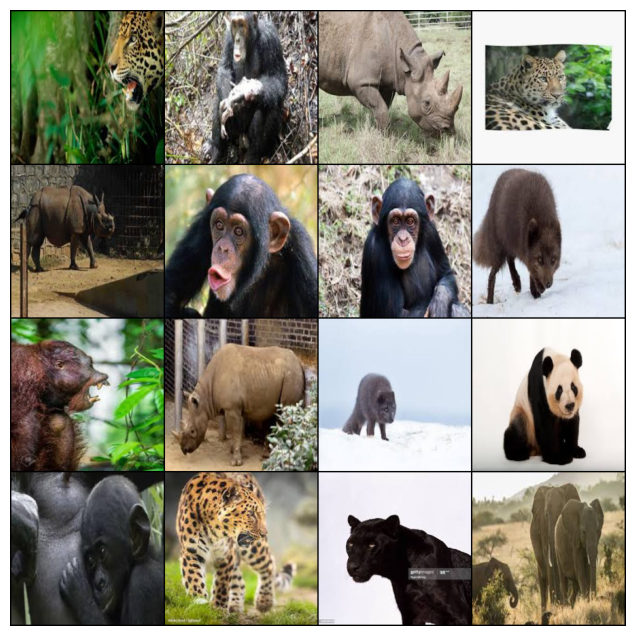

In [ ]:
# Get one batch from the dataloader
imgs, labels = next(iter(dl))

# Make a grid of the first 16 images
img_grid = torchvision.utils.make_grid(imgs[:16], nrow=4)

# Show the grid
plt.figure(figsize=(8,8))
plt.imshow(img_grid.permute(1, 2, 0))  # Convert to HWC format as pytorch uses CHW (Channel height width)
plt.axis('off')
plt.show()

In [ ]:
# here we can see that the dataset looks fine but we also have some random images like the SAT Math which is not really required

# **Validating the Dataset**

1.   Check folder and index
2.   Check the labels
3.   Check file extension



In [ ]:
# check the folder name --> and the index
print(ds.class_to_idx)

{'African_Elephant': 0, 'Amur_Leopard': 1, 'Arctic_Fox': 2, 'Chimpanzee': 3, 'Jaguars': 4, 'Lion': 5, 'Orangutan': 6, 'Panda': 7, 'Panthers': 8, 'Rhino': 9, 'cheetahs': 10}


In [ ]:
# Show first 10 file paths and their given label
for i in range(10):
    img_path, label = ds.samples[i]
    print(f"{img_path.split('/')[-2]} --> label: {label}")

African_Elephant --> label: 0
African_Elephant --> label: 0
African_Elephant --> label: 0
African_Elephant --> label: 0
African_Elephant --> label: 0
African_Elephant --> label: 0
African_Elephant --> label: 0
African_Elephant --> label: 0
African_Elephant --> label: 0
African_Elephant --> label: 0


In [ ]:
# List all file extensions
from collections import Counter
exts = Counter([f.split('.')[-1].lower() for cls in os.listdir(d0_path) for f in os.listdir(os.path.join(d0_path, cls))])
print(exts)

Counter({'jpg': 6308, 'jpeg': 113, 'png': 63})


# **Clean the data**

1.   Resize + convert images to tensor (we did that in the above section itself)
2.   Check for files with weird names (eg books)
3.   Images with low variance
4.   Convert to HWC format



In [ ]:
#Look for files that have weird names — like books in a zoo folder
for root, dirs, files in os.walk(d0_path):
    for f in files:
        if any(x in f.lower() for x in ['sat', 'math', 'logo', 'book', 'text']):
            print(os.path.join(root, f))

/content/endangered_species/Danger Of Extinction/cheetahs/Cheetahs-book_676x.jpg


In [ ]:
#collecting images that sound suspicious based on their names — but won’t delete anything yet
# Find all images with suspicious names
suspect_files = []

keywords = ['sat', 'book', 'text', 'math', 'logo', 'cover', 'draw']

for root, dirs, files in os.walk(d0_path):
    for f in files:
        if any(kw in f.lower() for kw in keywords):
            full_path = os.path.join(root, f)
            suspect_files.append(full_path)

# Print them
print("Suspicious Files by Name:")
for file in suspect_files:
    print(file)

Suspicious Files by Name:
/content/endangered_species/Danger Of Extinction/Lion/lion20cover.jpg
/content/endangered_species/Danger Of Extinction/Lion/Federico_Veronesi_Lions-cover-image-e359a4e.jpg
/content/endangered_species/Danger Of Extinction/Rhino/209903-cover.jpg
/content/endangered_species/Danger Of Extinction/cheetahs/Cheetahs-book_676x.jpg


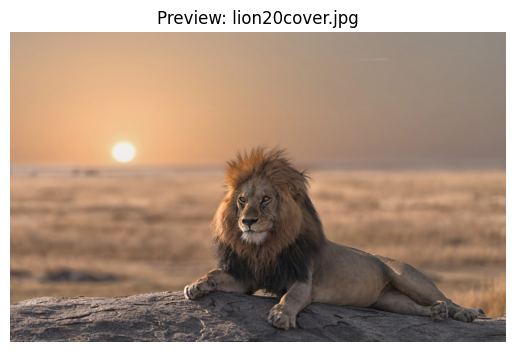

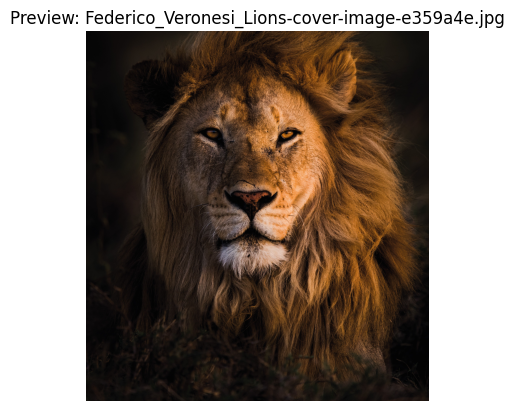

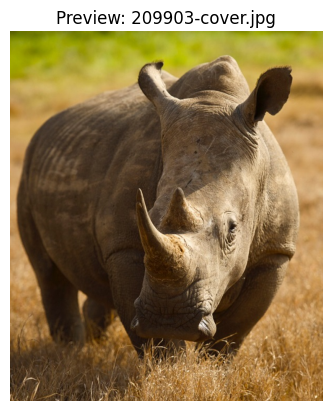

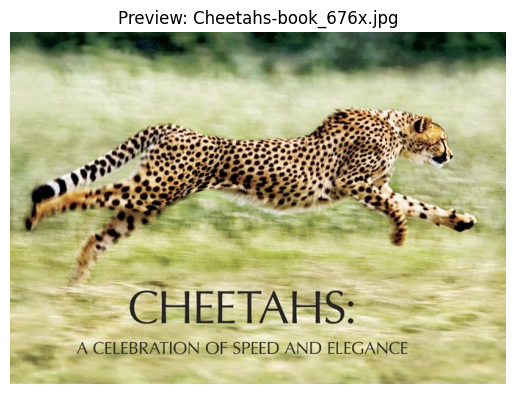

In [ ]:
for path in suspect_files:
    try:
        img = Image.open(path)
        plt.imshow(img)
        plt.title(f"Preview: {path.split('/')[-1]}")
        plt.axis('off')
        plt.show()
    except:
        print(f"Could not open: {path}")

In [ ]:
# this looks fine --> because the image names were suspicious but they are actual animals itself

In [ ]:
## lets look for pics with very low variance like a blank image
bad_by_variance = []

for root, _, files in os.walk(d0_path):
    for f in files:
        path = os.path.join(root, f)
        try:
            img = Image.open(path).convert('L')  # Convert to grayscale
            arr = np.array(img)
            if np.var(arr) < 100:  # Low pixel variation
                bad_by_variance.append(path)
        except:
            continue

# Show suspect ones
print("Low variance (possibly non-photo):")
for file in bad_by_variance:
    print(file)

Low variance (possibly non-photo):


In [ ]:
for root, _, files in os.walk(d0_path):
    for f in files:
        if 'sat' in f.lower():
            print(os.path.join(root, f))

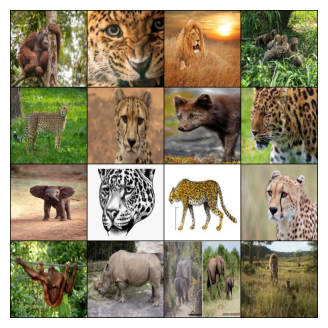

In [ ]:
# Get one batch from the dataloader
imgs, labels = next(iter(dl))

# Make a grid of the first 16 images
img_grid = torchvision.utils.make_grid(imgs[:16], nrow=4)

# Show the grid
plt.figure(figsize=(4,4))
plt.imshow(img_grid.permute(1, 2, 0))  # Convert to HWC format as pytorch uses CHW (Channel height width)
plt.axis('off')
plt.show()

In [ ]:
## Modelling

# **Modelling 1**

1.   Load pre-trained ResNet18
2.   Train and test split
3.   Apply ResNet18 to our data
4.   Evaluate the model



In [ ]:
# Load pre-trained ResNet18
res18_model = models.resnet18(pretrained=True)

# Freeze all layers this is optional for faster training
for param in res18_model.parameters():
    param.requires_grad = False

# Replace final layer for 11 classes
res18_model.fc = nn.Linear(res18_model.fc.in_features, 11)

# Send model to GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
res18_model = res18_model.to(device)

/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth
100%|██████████| 44.7M/44.7M [00:00<00:00, 77.6MB/s]


In [ ]:
# Load pretrained weights the new way
res18_model = resnet18(weights=ResNet18_Weights.DEFAULT)

In [ ]:
#define Loss function (for classification)
loss_fn = nn.CrossEntropyLoss()

# Optimizer (only training the final layer)
opt = optim.Adam(res18_model.fc.parameters(), lr=0.001)

In [ ]:
# 80-20 split into train and validation
train_size = int(0.8 * len(ds))
val_size = len(ds) - train_size

train_ds, val_ds = random_split(ds, [train_size, val_size])

In [ ]:
# Create data loaders for training and validation
train_dl = DataLoader(train_ds, batch_size=32, shuffle=True)
val_dl = DataLoader(val_ds, batch_size=32, shuffle=False)

In [ ]:
epochs = 2  # You can increase later taken only 2 as colab might take time to run

for epoch in range(epochs):
    res18_model.train()
    running_loss = 0.0

    for imgs, labels in train_dl:
        imgs, labels = imgs.to(device), labels.to(device)

        outputs = res18_model(imgs)
        loss = loss_fn(outputs, labels)

        opt.zero_grad()
        loss.backward()
        opt.step()

        running_loss += loss.item()

    print(f"Epoch {epoch+1}/{epochs}, Train Loss: {running_loss:.4f}")

Epoch 1/2, Train Loss: 342.8335
Epoch 2/2, Train Loss: 91.8752


In [ ]:
print(res18_model)

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [ ]:
correct = 0
total = 0

res18_model.eval()

with torch.no_grad():
    for imgs, labels in val_dl:
        imgs, labels = imgs.to(device), labels.to(device)

        outputs = res18_model(imgs)
        preds = torch.argmax(outputs, dim=1)

        correct += (preds == labels).sum().item()
        total += labels.size(0)

val_acc = 100 * correct / total
print(f"Validation Accuracy: {val_acc:.2f}%")

Validation Accuracy: 84.73%


In [ ]:
y_true = []
y_pred = []

res18_model.eval()

with torch.no_grad():
    for imgs, labels in val_dl:
        imgs, labels = imgs.to(device), labels.to(device)
        outputs = res18_model(imgs)
        preds = torch.argmax(outputs, dim=1)

        y_true.extend(labels.cpu().numpy())
        y_pred.extend(preds.cpu().numpy())

<Figure size 1000x1000 with 0 Axes>

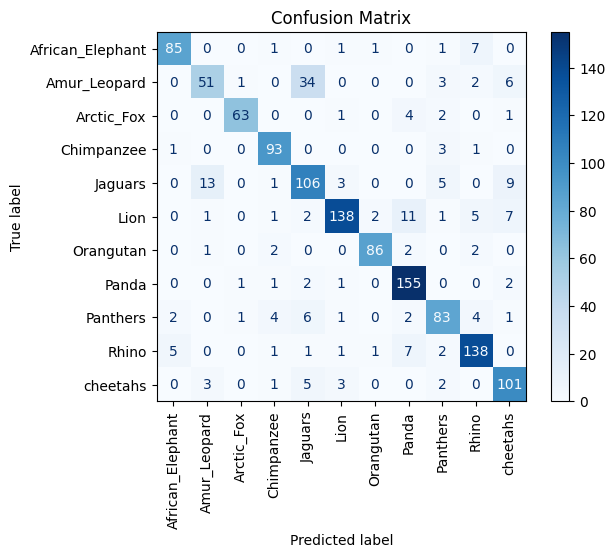

In [ ]:
cm = confusion_matrix(y_true, y_pred, labels=list(range(len(ds.classes))))
labels = ds.classes

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
plt.figure(figsize=(10, 10))
disp.plot(xticks_rotation='vertical', cmap='Blues')
plt.title("Confusion Matrix")
plt.show()

In [ ]:
# we can see from the confusion metrics that Amur leopard got confused with Jaguars

# **Modelling 2**

1.   Get more images
2.   Pre trained densenet
3.   Validate the model



In [ ]:
# Lets add more data as our model is confused between some animals. It works great for pandas

In [ ]:
# Adding images for Amur Leopard

!git clone https://github.com/monilshah98/amur_leopard_dectector_and_dataset.git

Cloning into 'amur_leopard_dectector_and_dataset'...
remote: Enumerating objects: 517, done.
remote: Counting objects: 100% (73/73), done.
remote: Compressing objects: 100% (32/32), done.
remote: Total 517 (delta 41), reused 72 (delta 40), pack-reused 444 (from 1)
Receiving objects: 100% (517/517), 121.49 MiB | 32.00 MiB/s, done.
Resolving deltas: 100% (264/264), done.
Updating files: 100% (414/414), done.


In [ ]:
# Source folder (from GitHub repo)
src = "/content/amur_leopard_dectector_and_dataset/train-images"

# The images are stored in our Amur_Leopard folder on the original path
dst = os.path.join(d0_path, "Amur_Leopard")

# Copy all new images into your existing folder
for file in os.listdir(src):
    if file.lower().endswith(('.jpg', '.jpeg', '.png')):
        shutil.copy(os.path.join(src, file), os.path.join(dst, file))

In [ ]:
print("New Amur Leopard total images:", len(os.listdir(dst)))

# before we had 530 now we added more 51 images

New Amur Leopard total images: 690


In [ ]:
for animal in os.listdir(d0_path):
    folder = os.path.join(d0_path, animal)
    count = len(os.listdir(folder))
    print(f"{animal}: {count} images")

Chimpanzee: 462 images
African_Elephant: 470 images
Amur_Leopard: 690 images
Lion: 806 images
Rhino: 773 images
Orangutan: 496 images
cheetahs: 590 images
Panthers: 565 images
Panda: 846 images
Arctic_Fox: 369 images
Jaguars: 577 images


In [ ]:
# lets add a better model
# Load pre-trained DenseNet201 with latest weights
dnet_model = densenet201(weights=DenseNet201_Weights.DEFAULT)

# Freeze all layers initially (we can unfreeze later if needed)
for param in dnet_model.parameters():
    param.requires_grad = False

# Replace the classifier to output 11 classes
import torch.nn as nn
dnet_model.classifier = nn.Linear(dnet_model.classifier.in_features, 11)

# Send to GPU if available
dnet_model = dnet_model.to(device)

In [ ]:
# Loss function (multi-class classification)
loss_fn = nn.CrossEntropyLoss()

# Optimizer — only train the classifier layer for now
opt = optim.Adam(dnet_model.classifier.parameters(), lr=0.001)


In [ ]:
epochs = 3  # we can increase to 5–10 for better performance

for epoch in range(epochs):
    dnet_model.train()
    running_loss = 0.0

    for imgs, labels in train_dl:
        imgs, labels = imgs.to(device), labels.to(device)

        outputs = dnet_model(imgs)
        loss = loss_fn(outputs, labels)

        opt.zero_grad()
        loss.backward()
        opt.step()

        running_loss += loss.item()

    print(f"Epoch {epoch+1}/{epochs}, Train Loss: {running_loss:.4f}")


Epoch 1/3, Train Loss: 102.6419
Epoch 2/3, Train Loss: 39.7404
Epoch 3/3, Train Loss: 29.8648


In [ ]:
correct = 0
total = 0

dnet_model.eval()

with torch.no_grad():
    for imgs, labels in val_dl:
        imgs, labels = imgs.to(device), labels.to(device)

        outputs = dnet_model(imgs)
        preds = torch.argmax(outputs, dim=1)

        correct += (preds == labels).sum().item()
        total += labels.size(0)

val_acc = 100 * correct / total
print(f"Validation Accuracy (DenseNet201): {val_acc:.2f}%")


Validation Accuracy (DenseNet201): 94.37%


In [ ]:
y_true = []
y_pred = []

dnet_model.eval()

with torch.no_grad():
    for imgs, labels in val_dl:
        imgs, labels = imgs.to(device), labels.to(device)
        outputs = dnet_model(imgs)
        preds = torch.argmax(outputs, dim=1)

        y_true.extend(labels.cpu().numpy())
        y_pred.extend(preds.cpu().numpy())


<Figure size 1000x1000 with 0 Axes>

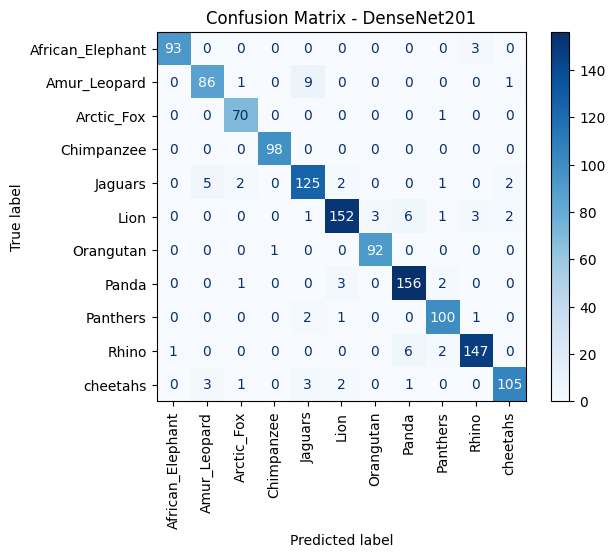

In [ ]:
cm = confusion_matrix(y_true, y_pred, labels=list(range(len(ds.classes))))
labels = ds.classes

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
plt.figure(figsize=(10, 10))
disp.plot(xticks_rotation='vertical', cmap='Blues')
plt.title("Confusion Matrix - DenseNet201")
plt.show()


In [ ]:
# Model results were improved now there are less number of images that were wrongly classified

# **Fine tune DenseNet201**

1.   Unfreeze the blocks
2.   Run the model
3.   Validate the results
4.   Use GradCam



In [ ]:
# Lets fine tune the model

In [ ]:
# Unfreeze the last few DenseNet blocks (we go deeper!)
for param in dnet_model.features[-3:].parameters():
    param.requires_grad = True

# Re-init optimizer to include new trainable params
opt = optim.Adam(filter(lambda p: p.requires_grad, dnet_model.parameters()), lr=1e-4)

In [ ]:
# Now I’m letting DenseNet learn more deeply — adjusting not just the final layer, but its internal brain too

epochs = 3  # You can adjust this based on Colab time
# But the first epoch itself gave less loss so model should work well even with 3 epochs

for epoch in range(epochs):
    dnet_model.train()
    running_loss = 0.0

    for imgs, labels in train_dl:
        imgs, labels = imgs.to(device), labels.to(device)

        outputs = dnet_model(imgs)
        loss = loss_fn(outputs, labels)

        opt.zero_grad()
        loss.backward()
        opt.step()

        running_loss += loss.item()

    print(f"Epoch {epoch+1}/{epochs}, Fine-Tuned Loss: {running_loss:.4f}")


Epoch 1/3, Fine-Tuned Loss: 27.2696
Epoch 2/3, Fine-Tuned Loss: 6.4199
Epoch 3/3, Fine-Tuned Loss: 3.5899


In [ ]:
correct = 0
total = 0

dnet_model.eval()

with torch.no_grad():
    for imgs, labels in val_dl:
        imgs, labels = imgs.to(device), labels.to(device)
        outputs = dnet_model(imgs)
        preds = torch.argmax(outputs, dim=1)

        correct += (preds == labels).sum().item()
        total += labels.size(0)

val_acc = 100 * correct / total
print(f"Validation Accuracy (Fine-Tuned): {val_acc:.2f}%")


Validation Accuracy (Fine-Tuned): 95.45%


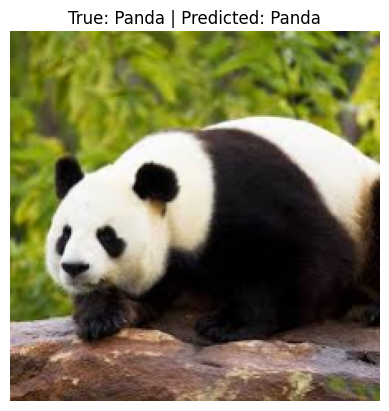

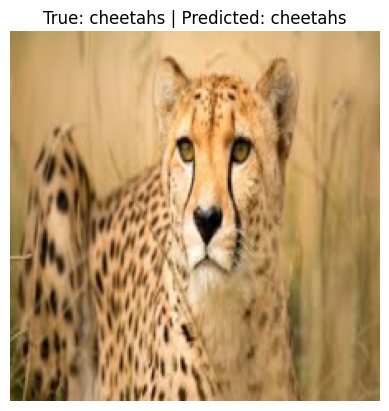

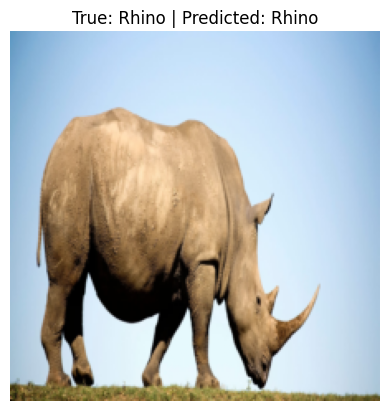

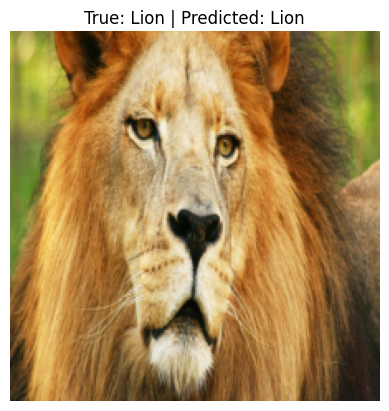

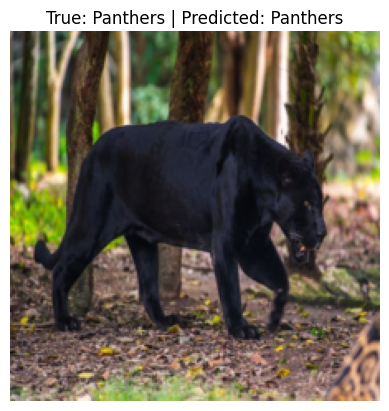

In [ ]:
# Get a batch from validation loader
imgs, labels = next(iter(val_dl))
imgs, labels = imgs.to(device), labels.to(device)

# Get predictions
dnet_model.eval()
with torch.no_grad():
    outputs = dnet_model(imgs)
    preds = torch.argmax(outputs, dim=1)

# Show 5 random samples
for i in range(5):
    img = imgs[i].cpu().permute(1, 2, 0)
    true_label = ds.classes[labels[i]]
    predicted_label = ds.classes[preds[i]]

    plt.imshow(img)
    plt.title(f"True: {true_label} | Predicted: {predicted_label}")
    plt.axis('off')
    plt.show()


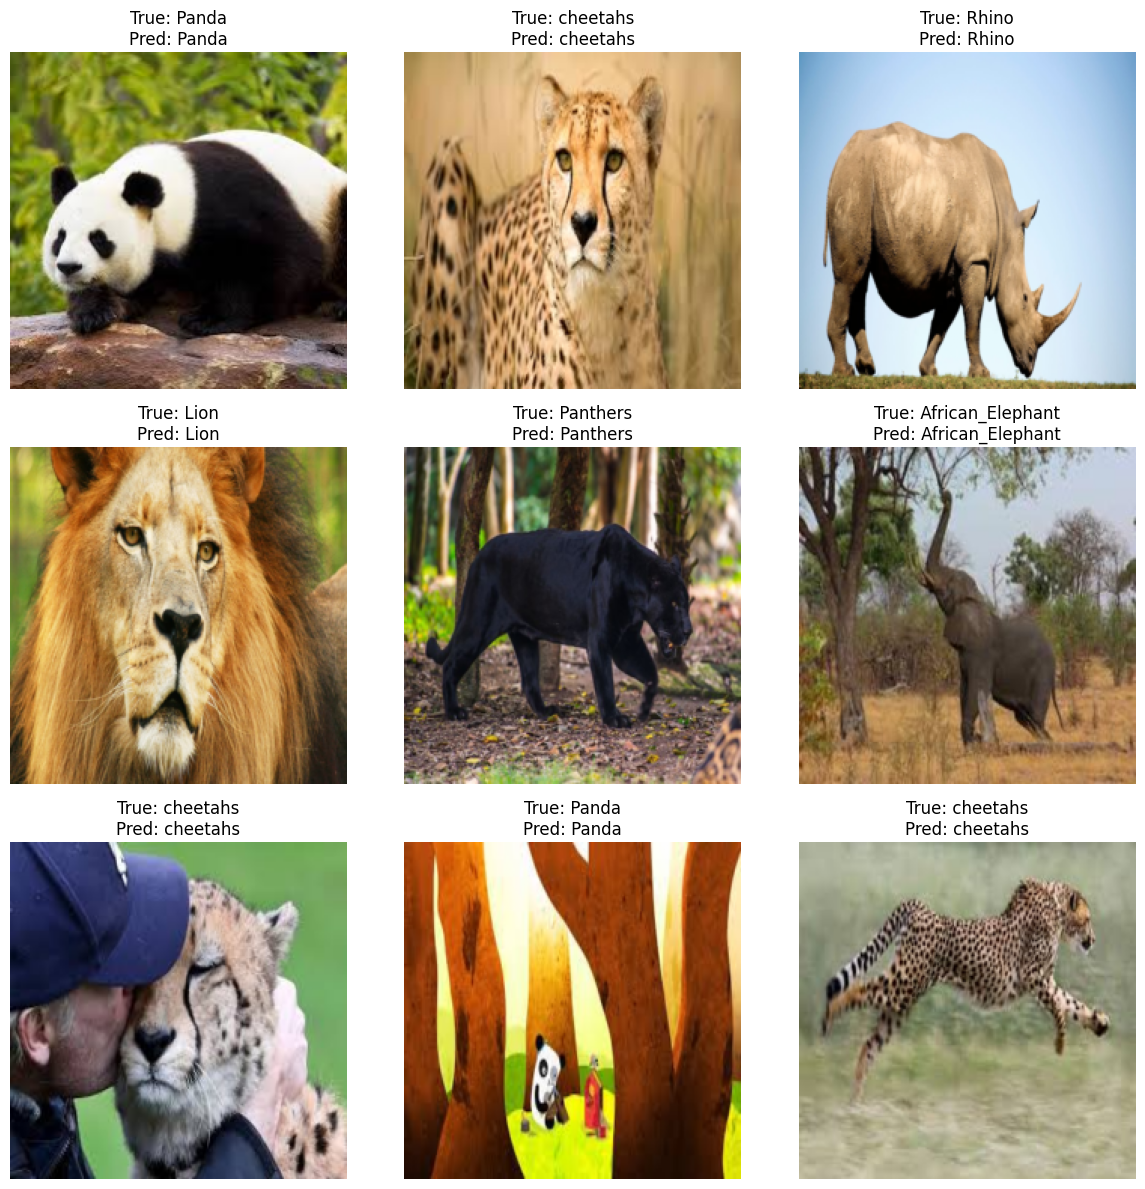

In [ ]:
# Get a batch of validation images
imgs, labels = next(iter(val_dl))
imgs, labels = imgs.to(device), labels.to(device)

# Make predictions
dnet_model.eval()
with torch.no_grad():
    outputs = dnet_model(imgs)
    preds = torch.argmax(outputs, dim=1)

# Plot grid of 9 images with predictions
plt.figure(figsize=(12, 12))

for i in range(9):
    img = imgs[i].cpu().permute(1, 2, 0)
    true_label = ds.classes[labels[i]]
    predicted_label = ds.classes[preds[i]]

    plt.subplot(3, 3, i + 1)
    plt.imshow(img)
    plt.title(f"True: {true_label}\nPred: {predicted_label}")
    plt.axis('off')

plt.tight_layout()
plt.show()


<Figure size 1000x1000 with 0 Axes>

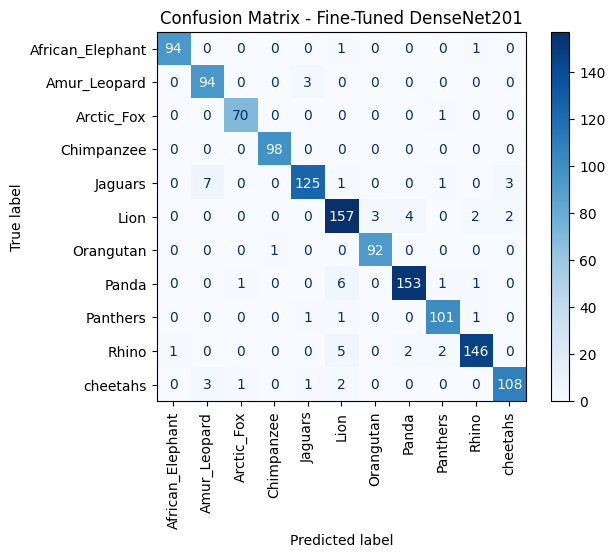

In [ ]:
y_true = []
y_pred = []

dnet_model.eval()
with torch.no_grad():
    for imgs, labels in val_dl:
        imgs, labels = imgs.to(device), labels.to(device)
        outputs = dnet_model(imgs)
        preds = torch.argmax(outputs, dim=1)

        y_true.extend(labels.cpu().numpy())
        y_pred.extend(preds.cpu().numpy())

cm = confusion_matrix(y_true, y_pred, labels=list(range(len(ds.classes))))
labels = ds.classes

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
plt.figure(figsize=(10, 10))
disp.plot(xticks_rotation='vertical', cmap='Blues')
plt.title("Confusion Matrix - Fine-Tuned DenseNet201")
plt.show()


In [ ]:
# grad cam

In [ ]:
# Rebuild the model
dnet_model = densenet201(weights=DenseNet201_Weights.DEFAULT)
dnet_model.classifier = nn.Linear(dnet_model.classifier.in_features, 11)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
dnet_model = dnet_model.to(device)


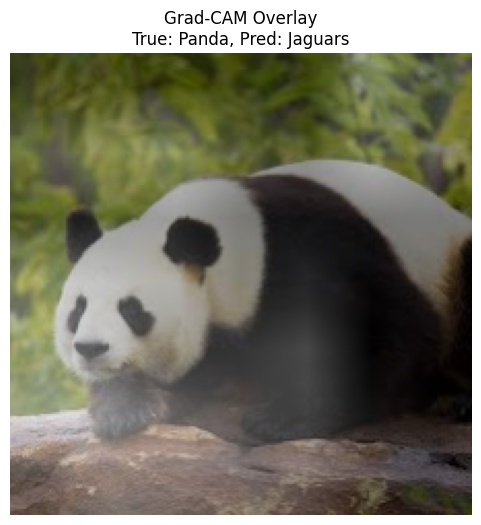

In [ ]:
# Grad-CAM setup
cam_extractor = GradCAM(model=dnet_model, target_layer="features.denseblock4")

# Get one image from validation loader
img, label = next(iter(val_dl))
img = img[0].unsqueeze(0).to(device)  # Add batch dimension
label = label[0].item()

# Forward pass
dnet_model.eval()
img.requires_grad = True
out = dnet_model(img)
pred_class = out.argmax(dim=1).item()

# Get Grad-CAM map
activation_map = cam_extractor(pred_class, out)
cam = activation_map[0].squeeze().cpu().numpy()
cam = (cam - cam.min()) / (cam.max() - cam.min())  # normalize to [0, 1]
cam = np.uint8(255 * cam)

# Resize heatmap using PIL
cam_img = Image.fromarray(cam).resize((224, 224), resample=Image.BILINEAR)
cam_img = np.array(cam_img)
cam_img = np.stack([cam_img]*3, axis=-1)  # convert to 3 channels

# Convert original image
img_show = to_pil_image(img[0].cpu())
img_np = np.array(img_show)

# Blend
overlay = 0.5 * img_np + 0.5 * cam_img
overlay = overlay.astype(np.uint8)

# Show result
plt.figure(figsize=(6, 6))
plt.imshow(overlay)
plt.title(f"Grad-CAM Overlay\nTrue: {ds.classes[label]}, Pred: {ds.classes[pred_class]}")
plt.axis('off')
plt.show()


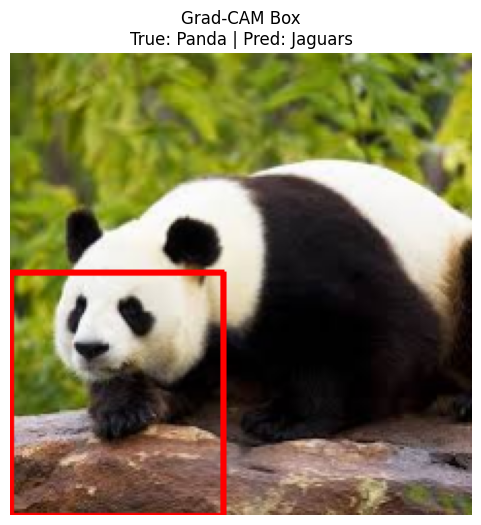

In [ ]:
# Grad-CAM setup
cam_extractor = GradCAM(model=dnet_model, target_layer="features.denseblock4")

# Get image
img, label = next(iter(val_dl))
img = img[0].unsqueeze(0).to(device)
label = label[0].item()

# Forward pass with gradients
dnet_model.eval()
img.requires_grad = True
out = dnet_model(img)
pred_class = out.argmax(dim=1).item()

# Extract Grad-CAM heatmap
activation_map = cam_extractor(pred_class, out)
cam = activation_map[0].squeeze().cpu().numpy()
cam = (cam - cam.min()) / (cam.max() - cam.min())  # normalize
cam = np.uint8(255 * cam)

# Resize heatmap to match image size (224x224)
cam_resized = cv2.resize(cam, (224, 224))

# Threshold the heatmap to find important region
_, thresh = cv2.threshold(cam_resized, 150, 255, cv2.THRESH_BINARY)

# Find contours from thresholded heatmap
contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

# Original image as array
img_show = to_pil_image(img[0].cpu())
img_np = np.array(img_show)

# Draw the largest contour bounding box
if contours:
    c = max(contours, key=cv2.contourArea)
    x, y, w, h = cv2.boundingRect(c)
    cv2.rectangle(img_np, (x, y), (x + w, y + h), (255, 0, 0), 2)  # blue box

# Show result
plt.figure(figsize=(6, 6))
plt.imshow(img_np)
plt.title(f"Grad-CAM Box\nTrue: {ds.classes[label]} | Pred: {ds.classes[pred_class]}")
plt.axis('off')
plt.show()


/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


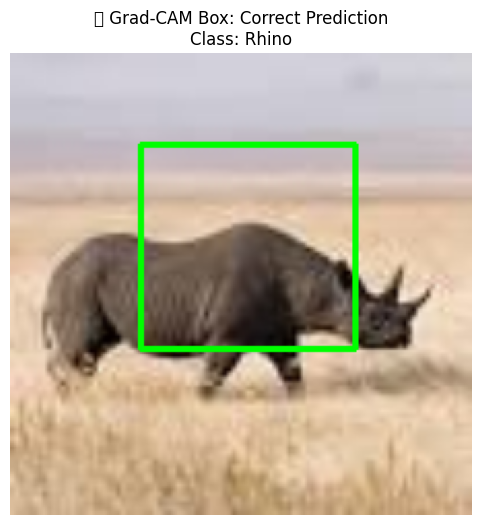

In [ ]:
# Setup Grad-CAM
cam_extractor = GradCAM(model=dnet_model, target_layer="features.denseblock4")

# Find the first correct prediction in validation set
for img_batch, label_batch in val_dl:
    img = img_batch[0].unsqueeze(0).to(device)
    true_label = label_batch[0].item()

    img.requires_grad = True
    dnet_model.eval()
    out = dnet_model(img)
    pred_class = out.argmax(dim=1).item()

    if pred_class == true_label:
        # Extract Grad-CAM map
        activation_map = cam_extractor(pred_class, out)
        cam = activation_map[0].squeeze().cpu().numpy()
        cam = (cam - cam.min()) / (cam.max() - cam.min())
        cam = np.uint8(255 * cam)
        cam_resized = cv2.resize(cam, (224, 224))

        # Threshold and get contour
        _, thresh = cv2.threshold(cam_resized, 150, 255, cv2.THRESH_BINARY)
        contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

        # Get original image
        img_show = to_pil_image(img[0].cpu())
        img_np = np.array(img_show)

        # Draw box around most focused area
        if contours:
            c = max(contours, key=cv2.contourArea)
            x, y, w, h = cv2.boundingRect(c)
            cv2.rectangle(img_np, (x, y), (x + w, y + h), (0, 255, 0), 2)  # green box

        # Show result
        plt.figure(figsize=(6, 6))
        plt.imshow(img_np)
        plt.title(f"✅ Grad-CAM Box: Correct Prediction\nClass: {ds.classes[pred_class]}")
        plt.axis('off')
        plt.show()
        break


In [ ]:
# Use of GenAI

# **Use of GenAI**

1.   Login to huggingface_hub
2.   Load Stable Diffusion Model
3.   Give a promt to convert to image



In [4]:
from huggingface_hub import notebook_login
notebook_login()

In [13]:
# Load Stable Diffusion model
pipe = StableDiffusionPipeline.from_pretrained(
    "runwayml/stable-diffusion-v1-5",
    torch_dtype=torch.float32  # using float32 instead of fp16
)
pipe = pipe.to("cuda" if torch.cuda.is_available() else "cpu")


/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model_index.json:   0%|          | 0.00/541 [00:00<?, ?B/s]

Fetching 15 files:   0%|          | 0/15 [00:00<?, ?it/s]

preprocessor_config.json:   0%|          | 0.00/342 [00:00<?, ?B/s]

scheduler_config.json:   0%|          | 0.00/308 [00:00<?, ?B/s]

...

config.json:   0%|          | 0.00/547 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/492M [00:00<?, ?B/s]

config.json:   0%|          | 0.00/743 [00:00<?, ?B/s]

diffusion_pytorch_model.safetensors:   0%|          | 0.00/335M [00:00<?, ?B/s]

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

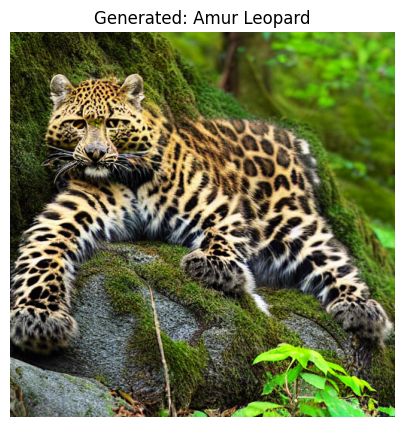

In [ ]:
prompt = "A realistic photo of an endangered Amur Leopard resting on a mossy rock in a forest"
image = pipe(prompt).images[0]

# Show the generated image
import matplotlib.pyplot as plt
plt.figure(figsize=(5, 5))
plt.imshow(image)
plt.title("Generated: Amur Leopard")
plt.axis("off")
plt.show()


In [1]:
# So now we have more clear image of amur leopard we can use this synthetic images to train our model even better
# we can also get images of animals that are very extinct and we dont have images for that at all

  0%|          | 0/50 [00:00<?, ?it/s]

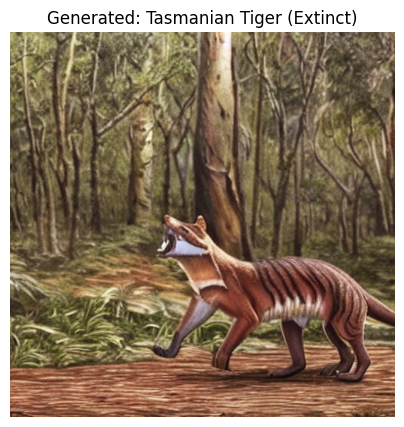

In [14]:
prompt = "A realistic photo of a Tasmanian Tiger (Thylacine) walking in an Australian forest, extinct animal"
image = pipe(prompt).images[0]

plt.figure(figsize=(5, 5))
plt.imshow(image)
plt.title("Generated: Tasmanian Tiger (Extinct)")
plt.axis("off")
plt.show()